In [1]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A
import numpy as np
from collections import Counter

DATASET_PATH = "/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask):
    transform = A.Compose([
        A.HorizontalFlip(p=1),
        A.VerticalFlip(p=1),
        A.Rotate(limit=45, p=1),
    ])

    augmented = transform(image=image, mask=mask)
    return augmented["image"], augmented["mask"]



def balance_classes(images, masks, labels, augment_data):

   
    class_counts = Counter(labels)
    max_count = max(class_counts.values())  

    balanced_images = []
    balanced_masks = []
    balanced_labels = []

    for class_index in class_counts.keys():
        class_images = [img for img, lbl in zip(images, labels) if lbl == class_index]
        class_masks = [mask for mask, lbl in zip(masks, labels) if lbl == class_index]

        current_count = len(class_images)


        while current_count < max_count:
            for img, mask in zip(class_images, class_masks):
                aug_img, aug_mask = augment_data(img, mask)  
                balanced_images.append(aug_img)
                balanced_masks.append(aug_mask)
                balanced_labels.append(class_index)
                current_count += 1
                if current_count >= max_count:
                    break

       
        balanced_images.extend(class_images)
        balanced_masks.extend(class_masks)
        balanced_labels.extend([class_index] * len(class_images))

    return (np.array(balanced_images, dtype=np.float32).reshape(-1, 128, 128, 1),
            np.array(balanced_masks, dtype=np.float32).reshape(-1, 128, 128, 1),
            np.array(balanced_labels, dtype=np.int32))


def load_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []

    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, "image", str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))

        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue

                image = cv2.resize(image, target_size)
                image = image / 255.0

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0

                    # Add image and mask
                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)

                    # Augmented data
                    aug_image, aug_mask = augment_data(image, mask)
                    images.append(aug_image)
                    masks.append(aug_mask)
                    labels.append(class_index)

    # balanced the data :
    images, masks, labels = balance_classes(images, masks, labels, augment_data) # Pass the augment_data function as an argument

    return images, masks, labels

def split_data(images, masks, labels, test_size=0.2):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )
    return Img_train, Img_test, label_train, label_test, mask_train, mask_test

if __name__ == "__main__":
    images, masks, labels = load_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"Number of images: {images.shape[0]}, Number of masks: {masks.shape[0]}, Number of labels: {labels.shape[0]}")
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = split_data(images, masks, labels, test_size=0.2)
    print(f"Training data: {Img_train.shape[0]} | Test data: {Img_test.shape[0]}")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Loading pituitary_tumor: 100%|██████████| 994/994 [00:17<00:00, 57.42it/s]


Number of images: 12760, Number of masks: 12760, Number of labels: 12760
Training data: 10208 | Test data: 2552


In [2]:
print('labels vector',labels)
# encoding the label using OneHotEncoder :
#train label :
encoder_labels_train=np.array(label_train)
encoder_labels_train=np.eye(4)[encoder_labels_train]
print('the encoded vector of train  : ',encoder_labels_train)
#test label :
encoder_labels_test=np.array(label_test)
encoder_labels_test=np.eye(4)[encoder_labels_test]
print('the encoded vector of test  : ',encoder_labels_test)



labels vector [0 0 0 ... 3 3 3]
the encoded vector of train  :  [[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 ...
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
the encoded vector of test  :  [[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 ...
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten,BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LeakyReLU


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping


def CNN_model(f1, f2, f3, f4, k1, k2, k3, k4, a1, a2, a3, a4, d1, d2, d3, d4, d5, d6, op, lr, ep, 
              Img_train, encoder_labels_train, num_classes=4):
    model = models.Sequential()

    
    model.add(layers.Input(shape=(128, 128, 1)))

   
    model.add(layers.Conv2D(f1, (k1, k1), activation=a1))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(f2, (k2, k2), activation=a2, kernel_regularizer=regularizers.l2(0.0001)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(d1))

    model.add(layers.Conv2D(f3, (k3, k3), activation=a3, kernel_regularizer=regularizers.l2(0.0005)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(d2))

    model.add(layers.Conv2D(f4, (k4, k4), activation=a4, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(d3))

    
    model.add(layers.Flatten())

   
    model.add(layers.Dense(f4, kernel_regularizer=regularizers.l2(0.0005)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.Dropout(d4))

    model.add(layers.Dense(f3, kernel_regularizer=regularizers.l2(0.0005)))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.Dropout(d5))

   
    model.add(layers.Dense(num_classes, activation='softmax'))

   
    optimizers_dict = {"adam": optimizers.Adam, "sgd": optimizers.SGD, "rmsprop": optimizers.RMSprop, "adamax": optimizers.Adamax}
    optimizer = optimizers_dict.get(op, optimizers.Adam)(learning_rate=lr)  

    
    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

    
    es = EarlyStopping(monitor="val_accuracy", patience=7)
    history = model.fit(Img_train, encoder_labels_train, validation_split=0.2, 
                        epochs=ep, batch_size=100, callbacks=[es], verbose=0)

    return model, history  


In [ ]:
from random import choice, uniform, randint

def initialization():
    parameters = {}

    
    parameters["f1"] = choice([32, 64])
    parameters["f2"] = choice([64, 128])
    parameters["f3"] = choice([128, 256])
    parameters["f4"] = choice([256, 512])

    
    parameters["k1"] = choice([3, 5])
    parameters["k2"] = choice([3, 5])
    parameters["k3"] = choice([3, 5])
    parameters["k4"] = choice([3, 5])

    
    parameters["a1"] = choice(["relu", "selu", "elu"])
    parameters["a2"] = choice(["relu", "selu", "elu"])
    parameters["a3"] = choice(["relu", "selu", "elu"])
    parameters["a4"] = choice(["relu", "selu", "elu"])

    
    parameters["d1"] = round(uniform(0.1, 0.5), 1)
    parameters["d2"] = round(uniform(0.1, 0.5), 1)
    parameters["d3"] = round(uniform(0.1, 0.5), 1)
    parameters["d4"] = round(uniform(0.1, 0.5), 1)
    parameters["d5"] = round(uniform(0.1, 0.5), 1)
    parameters["d6"] = round(uniform(0.1, 0.5), 1)

    
    parameters["op"] = choice(["adam", "sgd", "rmsprop", "adamax"])

    
    parameters["lr"] = round(uniform(0.0001, 0.01), 5)  

   
    parameters["ep"] = randint(50, 100)

    return parameters


sample_parameters = initialization()
print(sample_parameters)


{'f1': 32, 'f2': 128, 'f3': 256, 'f4': 256, 'k1': 3, 'k2': 3, 'k3': 3, 'k4': 5, 'a1': 'elu', 'a2': 'selu', 'a3': 'relu', 'a4': 'selu', 'd1': 0.2, 'd2': 0.4, 'd3': 0.3, 'd4': 0.5, 'd5': 0.3, 'd6': 0.4, 'op': 'rmsprop', 'lr': 0.00574, 'ep': 99}


In [6]:
def generate_population(n):
  population = []
  for i in range(n):
    chromosome = initialization()
    population.append(chromosome)
  return population

In [ ]:

# Roulette wheel selection method
from random import choice, choices

def selection(population_fitness):
    total = sum(population_fitness)

    
    if total == 0:
        print("⚠️ Warning: No valid individuals! Selecting randomly.")
        return choices(range(len(population_fitness)), k=2) 

    
    percentage = [round((x / total) * 100) for x in population_fitness]

    
    selection_wheel = []
    for pop_index, num in enumerate(percentage):
        selection_wheel.extend([pop_index] * num)

    
    if not selection_wheel:
        print("⚠️ Warning: Empty selection wheel! Selecting randomly.")
        return choices(range(len(population_fitness)), k=2)

    
    parent1_ind = choice(selection_wheel)
    parent2_ind = choice(selection_wheel)

    return [parent1_ind, parent2_ind]


In [ ]:
from random import choice

def crossover(parent1, parent2):
    child1, child2 = {}, {}

   
    child1["f1"], child2["f1"] = choice([parent1["f1"], parent2["f1"]]), choice([parent1["f1"], parent2["f1"]])
    child1["f2"], child2["f2"] = choice([parent1["f2"], parent2["f2"]]), choice([parent1["f2"], parent2["f2"]])
    child1["f3"], child2["f3"] = choice([parent1["f3"], parent2["f3"]]), choice([parent1["f3"], parent2["f3"]])
    child1["f4"], child2["f4"] = choice([parent1["f4"], parent2["f4"]]), choice([parent1["f4"], parent2["f4"]])

    
    child1["k1"], child2["k1"] = choice([parent1["k1"], parent2["k1"]]), choice([parent1["k1"], parent2["k1"]])
    child1["k2"], child2["k2"] = choice([parent1["k2"], parent2["k2"]]), choice([parent1["k2"], parent2["k2"]])
    child1["k3"], child2["k3"] = choice([parent1["k3"], parent2["k3"]]), choice([parent1["k3"], parent2["k3"]])
    child1["k4"], child2["k4"] = choice([parent1["k4"], parent2["k4"]]), choice([parent1["k4"], parent2["k4"]])

    
    child1["a1"], child2["a1"] = choice([parent1["a1"], parent2["a1"]]), choice([parent1["a1"], parent2["a1"]])
    child1["a2"], child2["a2"] = choice([parent1["a2"], parent2["a2"]]), choice([parent1["a2"], parent2["a2"]])
    child1["a3"], child2["a3"] = choice([parent1["a3"], parent2["a3"]]), choice([parent1["a3"], parent2["a3"]])
    child1["a4"], child2["a4"] = choice([parent1["a4"], parent2["a4"]]), choice([parent1["a4"], parent2["a4"]])

    
    child1["d1"], child2["d1"] = choice([parent1["d1"], parent2["d1"]]), choice([parent1["d1"], parent2["d1"]])
    child1["d2"], child2["d2"] = choice([parent1["d2"], parent2["d2"]]), choice([parent1["d2"], parent2["d2"]])
    child1["d3"], child2["d3"] = choice([parent1["d3"], parent2["d3"]]), choice([parent1["d3"], parent2["d3"]])
    child1["d4"], child2["d4"] = choice([parent1["d4"], parent2["d4"]]), choice([parent1["d4"], parent2["d4"]])
    child1["d5"], child2["d5"] = choice([parent1["d5"], parent2["d5"]]), choice([parent1["d5"], parent2["d5"]])
    child1["d6"], child2["d6"] = choice([parent1["d6"], parent2["d6"]]), choice([parent1["d6"], parent2["d6"]])

    
    child1["op"], child2["op"] = choice([parent1["op"], parent2["op"]]), choice([parent1["op"], parent2["op"]])

    
    child1["lr"], child2["lr"] = choice([parent1["lr"], parent2["lr"]]), choice([parent1["lr"], parent2["lr"]])

   
    child1["ep"], child2["ep"] = choice([parent1["ep"], parent2["ep"]]), choice([parent1["ep"], parent2["ep"]])

    return [child1, child2]


In [9]:
def mutation(chromosome):
  flag = randint(0,40)
  if flag <= 20:
    chromosome["ep"] += randint(0, 10)
  return chromosome

In [ ]:
import pickle
import os
from tensorflow.keras.models import load_model


generations = 10  

num_pop = 20  



population = [initialization() for i in range(num_pop)]


def fitness_evaluation(model):
    i, accuracy = model.evaluate(Img_test, encoder_labels_test, verbose=0)
    return accuracy * 100  


best_accuracy = 0  
best_model = None  
best_history = None  


for generation in range(generations):
    population_fitness = []
    generation_best_acc = 0  

    for chromosome in population:
        f1, f2, f3, f4 = chromosome["f1"], chromosome["f2"], chromosome["f3"], chromosome["f4"]
        k1, k2, k3, k4 = chromosome["k1"], chromosome["k2"], chromosome["k3"], chromosome["k4"]
        a1, a2, a3, a4 = chromosome["a1"], chromosome["a2"], chromosome["a3"], chromosome["a4"]
        d1, d2, d3, d4, d5, d6 = chromosome["d1"], chromosome["d2"], chromosome["d3"], chromosome["d4"], chromosome["d5"], chromosome["d6"]
        op, lr, ep = chromosome["op"], chromosome["lr"], chromosome["ep"]

        try:
         
            model, history = CNN_model(f1, f2, f3, f4, k1, k2, k3, k4, a1, a2, a3, a4, 
                                       d1, d2, d3, d4, d5, d6, op, lr, ep, 
                                       Img_train, encoder_labels_train)
            
            acc = fitness_evaluation(model)
            print(f"✅ Parameters: {chromosome}\n🔹 Accuracy: {round(acc, 3)}%")

           
            if acc > best_accuracy:
                best_accuracy = acc
                best_model = model
                best_history = history
                no_improvement_generations = 0 
                
                
                model.save("best_model.h5")
                with open("best_history.pkl", "wb") as f:
                    pickle.dump(history.history, f)

                print(f"💾 Saved best model with accuracy: {best_accuracy}%")

            
            if acc > 0:
                generation_best_acc = max(generation_best_acc, acc)

        except Exception as e:
            acc = 0
            print(f"❌ Invalid parameters - Build failed\n🔹 Parameters: {chromosome}\n🔹 Error: {e}")

        population_fitness.append(acc)


   
    parents_ind = selection(population_fitness)
    parent1, parent2 = population[parents_ind[0]], population[parents_ind[1]]

    
    children = crossover(parent1, parent2)
    child1, child2 = mutation(children[0]), mutation(children[1])

    
    population.append(child1)
    population.append(child2)

   
    print(f"\n🚀 Generation {generation + 1} Outcome:")
    print(f"📈 Maximum accuracy in generation {generation + 1}: {generation_best_acc}%")

    
    if len(population) > num_pop:
        for i in range(2):
            if len(population_fitness) > 0:
                min_fitness = min(population_fitness)
                min_index = population_fitness.index(min_fitness)
                del population[min_index]
                del population_fitness[min_index]


print(f"\n🏆 Best Model Achieved Accuracy: {best_accuracy}%")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


✅ Parameters: {'f1': 64, 'f2': 64, 'f3': 256, 'f4': 512, 'k1': 3, 'k2': 5, 'k3': 5, 'k4': 5, 'a1': 'elu', 'a2': 'selu', 'a3': 'selu', 'a4': 'selu', 'd1': 0.3, 'd2': 0.4, 'd3': 0.5, 'd4': 0.1, 'd5': 0.1, 'd6': 0.5, 'op': 'rmsprop', 'lr': 0.0094, 'ep': 83}
🔹 Accuracy: 51.646%
💾 Saved best model with accuracy: 51.64576768875122%
✅ Parameters: {'f1': 32, 'f2': 128, 'f3': 256, 'f4': 512, 'k1': 5, 'k2': 3, 'k3': 3, 'k4': 3, 'a1': 'selu', 'a2': 'elu', 'a3': 'elu', 'a4': 'selu', 'd1': 0.2, 'd2': 0.2, 'd3': 0.3, 'd4': 0.3, 'd5': 0.4, 'd6': 0.3, 'op': 'adam', 'lr': 0.00225, 'ep': 83}
🔹 Accuracy: 77.038%
💾 Saved best model with accuracy: 77.03761458396912%
✅ Parameters: {'f1': 32, 'f2': 64, 'f3': 256, 'f4': 256, 'k1': 3, 'k2': 5, 'k3': 3, 'k4': 3, 'a1': 'relu', 'a2': 'relu', 'a3': 'elu', 'a4': 'relu', 'd1': 0.2, 'd2': 0.3, 'd3': 0.4, 'd4': 0.4, 'd5': 0.3, 'd6': 0.4, 'op': 'adamax', 'lr': 0.00108, 'ep': 58}
🔹 Accuracy: 88.558%
💾 Saved best model with accuracy: 88.55799436569214%
✅ Parameters: {'f1

In [ ]:
from sklearn.metrics import classification_report
import numpy as np


y_pred_prob = model.predict(Img_test, batch_size=16)


y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(encoder_labels_test, axis=1) 


report = classification_report(y_true, y_pred)

print(report)


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, Img_test, encoder_labels_test, num_samples=5):
    indices = np.random.choice(len(Img_test), num_samples, replace=False)
    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_label = np.argmax(encoder_labels_test[idx])  # Convert one-hot to class index

        test_image_input = np.expand_dims(test_image, axis=0)
        pred_label = model.predict(test_image_input).argmax(axis=1)[0]  # Predicted class label

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title(f"True: {true_label} | Pred: {pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Définir le modèle en passant Img_train et encoder_labels_train
model,history = CNN_model(64, 64, 256, 256, 5, 5, 5, 5, 'relu', 'elu', 'elu', 'elu', 
                  0.2, 0.3, 0.1, 0.3, 0.1, 0.1, 'adamax', 0.00613, 88, 
                  Img_train, encoder_labels_train)



# Tester le modèle sur 5 échantillons
test_model(model, Img_test, encoder_labels_test, num_samples=5)


In [3]:
import pickle

with open(r'C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Saves\Cls_ga\best_history (1).pkl', 'rb') as file:
    history = pickle.load(file)

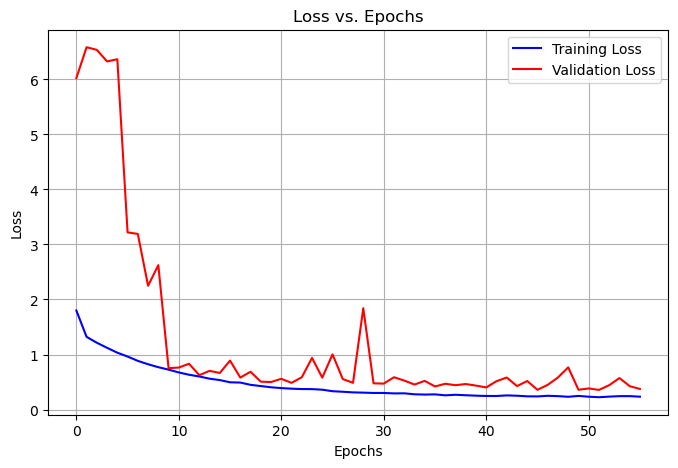

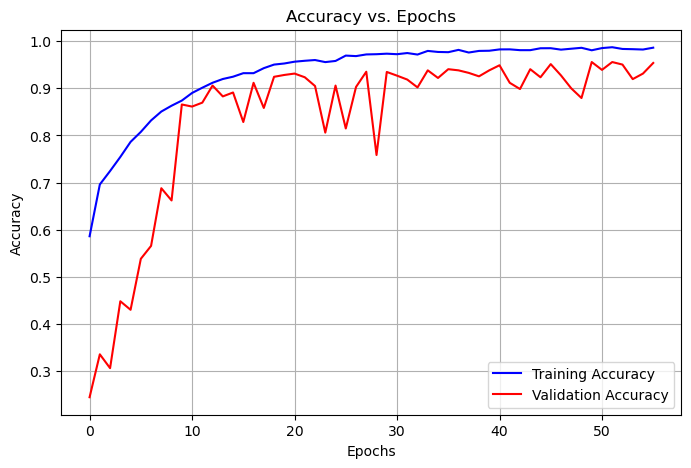

In [10]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


if hasattr(history, r'C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Saves\Cls_ga\best_history (1).pkl'):  
    history = history.history  

train_loss = history['loss']
val_loss = history['val_loss']


plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')


plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()




train_acc = history['accuracy']
val_acc = history['val_accuracy']


plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid()
plt.show()